<a href="https://colab.research.google.com/github/SandeshRoy/churn-prediction-system/blob/main/Temperature_Prediction_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157119 entries, 0 to 157118
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    157119 non-null  int64  
 1   lat          157119 non-null  float64
 2   lon          157119 non-null  float64
 3   pressure     157119 non-null  float64
 4   temperature  157119 non-null  float64
 5   humidity     157118 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 7.2 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [ ]:
# Check for missing values
df.isnull().sum()

# Display summary statistics
df.describe()



,sensor_id,lat,lon,pressure,temperature,humidity
count,157119.000000,157119.000000,157119.000000,157119.000000,157119.000000,157118.000000
mean,2707.696873,42.680215,23.334980,95007.831703,25.435401,47.936478
std,694.573344,0.025958,0.040196,664.772656,6.927153,22.039071
min,1764.000000,42.622000,23.254000,92061.020000,11.940000,0.000000
25%,2224.000000,42.664000,23.310000,94659.745000,19.830000,31.650000
50%,2294.000000,42.685000,23.332000,95078.070000,24.530000,48.050000
75%,3438.000000,42.694000,23.360000,95507.670000,29.720000,64.480000
max,3982.000000,42.738000,23.419000,96196.300000,60.470000,100.000000


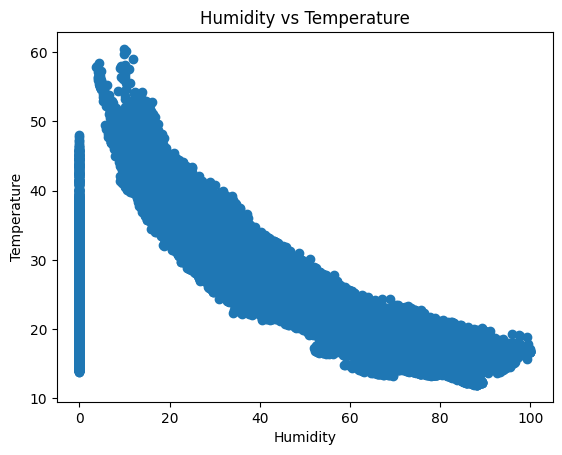

In [ ]:
# Scatter plot to observe relationship
plt.scatter(df['humidity'], df['temperature'])

plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Humidity vs Temperature")

plt.show()

## Data Preprocessing

In [ ]:
# Drop any rows with missing values
df = df.dropna()


# Define features and target
X = df[['humidity']]
y = df['temperature']


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Training

In [ ]:
# Linear Regression
model = LinearRegression()

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


## Evaluation


In [ ]:
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 18.165089879052807
R2 Score: 0.6173170500727688


## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.
